<a href="https://colab.research.google.com/github/qaiserxd/machine-learning-scikit-learn/blob/master/mnist_stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# Load MNIST data from OpenML
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

# Normalize pixel values
X = X.astype('float32') / 255.0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

# Reshape to 2D images if needed for visualization or CNNs
X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

print(f"Data loaded. X_train shape: {X_train.shape}")

Fetching MNIST dataset...
Data loaded. X_train shape: (60000, 784)


In [2]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode the labels using sklearn
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Encoded labels shape: {y_train_encoded.shape}")
print(f"Example of first encoded label: {y_train_encoded[0]}")

Encoded labels shape: (60000, 10)
Example of first encoded label: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [3]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the 5 base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('svc', SVC(probability=True, kernel='rbf', C=1, random_state=42))
]

# Initialize Stacking Classifier
stack_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=3,
    n_jobs=-1
)

# Using a subset for demonstration to keep execution time reasonable
# MNIST is large, so training 5 models + stacking can take time
print("\nTraining Stacking Classifier...")
stack_clf.fit(X_train[:30000], y_train[:30000])

# Evaluate the model
y_pred = stack_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)

print(f"Stacking Ensemble Accuracy: {score:.4f}")



Training Stacking Classifier...
Stacking Ensemble Accuracy: 0.9763


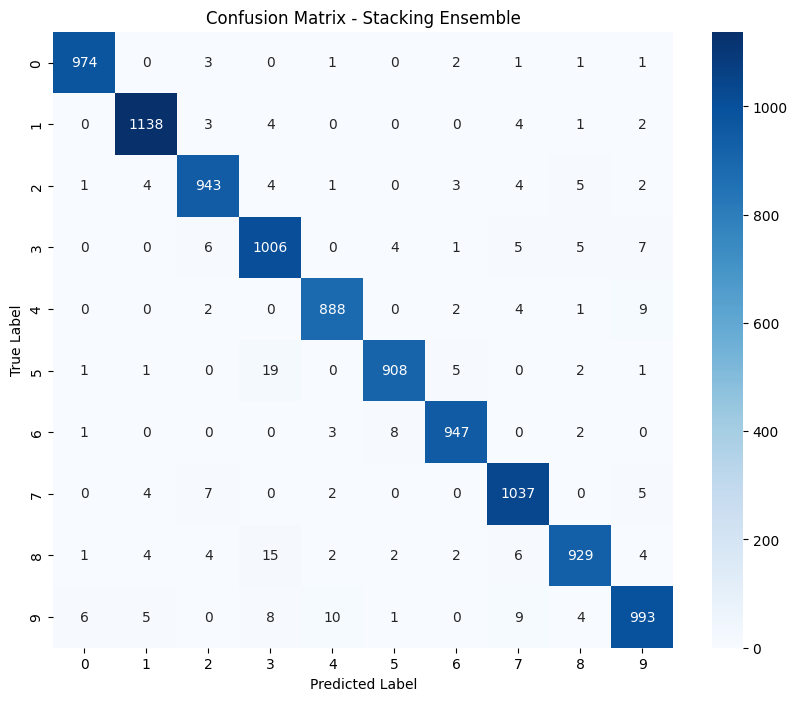

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Visualize the performance with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()